# Maritime Search & Rescue Object Detection using YOLO11n

This notebook presents the baseline training pipeline for **SentinelBlue**, a UAV-centric maritime Search and Rescue perception system designed with a strong emphasis on realistic deployment constraints. SentinelBlue prioritizes high-quality dataset engineering, controlled augmentation, and reproducible experimentation over architectural novelty, ensuring that the resulting models reflect practical SAR perception requirements rather than purely benchmark-driven optimization.

The dataset integrates SeaDronesSee with carefully selected complementary sources and applies targeted augmentation exclusively within the training split to address minority class scarcity while preserving validation and test integrity. The final taxonomy includes person, boat, jetski, buoy, and emergency_appliance, reflecting operational SAR targets.

This notebook establishes the YOLO11n baseline, providing a balanced starting point for future SentinelBlue experiments involving resolution scaling, edge optimization, and deployment-aware evaluation.

## Environment Setup

This section prepares the training environment by installing the Ultralytics framework and configuring the runtime for controlled experimentation within Kaggle. Ensuring a clean and reproducible environment is particularly important for SentinelBlue because the project emphasizes methodological clarity and experiment traceability across iterations.

External experiment tracking is disabled to prevent unintended logging overhead and to keep all artifacts contained within the notebook workspace. After installation, a lightweight verification step confirms that the Ultralytics package is correctly initialized and that the runtime can access GPU acceleration. Establishing this baseline environment reduces the risk of hidden configuration issues that could affect training stability or reproducibility in later experiments.

In [1]:
# Install Ultralytics
!pip install -q ultralytics

# Disable external logging for reproducibility
import os
os.environ["WANDB_DISABLED"] = "true"

# Verify installation and environment
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6672.9/8062.4 GB disk)


## Dataset Configuration

SentinelBlue follows the standard YOLO directory structure, where images and labels are separated by split and linked through a central YAML configuration file. Because the dataset has already undergone a full engineering cycle including balancing, augmentation, and integrity validation, this notebook does not perform many dataset modifications and treats the data as more or less frozen.

The YAML file defines class mappings and split paths, allowing the training pipeline to remain concise while ensuring consistency across experiments. Maintaining a stable dataset reference is essential for SentinelBlue, as it enables reliable comparison between training iterations and supports reproducible research reporting. The configuration paths below are used directly during training and later during full test-set inference.

## Model Training - YOLO11n

This section trains the SentinelBlue baseline using YOLO11n with an explicit training configuration that mirrors the structured experimentation approach adopted throughout the project. Rather than relying on default parameters, key optimization and augmentation settings are specified directly to ensure reproducibility and clear experimental traceability across iterations.

The configuration preserves conservative geometric augmentation because SentinelBlue already incorporates extensive dataset-level augmentation. Photometric variation and moderate scale transformations are retained to maintain robustness to real maritime imaging conditions. The training run is organized under a dedicated project directory, enabling systematic tracking of metrics, checkpoints, and qualitative outputs. 

In [2]:
!nvidia-smi

Sat Mar  7 22:51:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!yolo task=detect mode=train \
model=yolo11n.pt \
data=/kaggle/input/sentinelblue/data.yaml \
epochs=30 \
patience=20 \
imgsz=640 \
batch=192 \
lr0=0.007 \
device=0,1 \
workers=12 \
project=training_iteration_1 \
name=training_iteration_1 \
save=True \
save_period=5 \
hsv_h=0.015 \
hsv_s=0.7 \
hsv_v=0.4 \
degrees=0 \
translate=0.1 \
scale=0.4 \
shear=0.0 \
perspective=0.0 \
flipud=0 \
fliplr=0.5 \
mosaic=1.0 \
mixup=0.05 \
copy_paste=0.01 \
amp=True

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=192, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.01, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/sentinelblue/data.yaml, degrees=0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.007, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_iteration_1, nbs=6

## Training Metrics Inspection

After training completes, the first step is to examine the recorded learning curves to verify that optimization progressed in a stable and meaningful manner. Ultralytics automatically logs losses and evaluation metrics across epochs, allowing detailed inspection of convergence behaviour without additional instrumentation. For SentinelBlue, these curves are particularly important because the dataset underwent extensive engineering and controlled augmentation prior to training.

Observing bounding box loss stabilization indicates localization learning, while classification and distribution losses reflect how well the model separates SAR classes with varying frequency. The evolution of mAP metrics provides a concise summary of detection quality over time. Consistent downward loss trends combined with steady mAP improvement suggest that the dataset design and training configuration are functioning as intended.

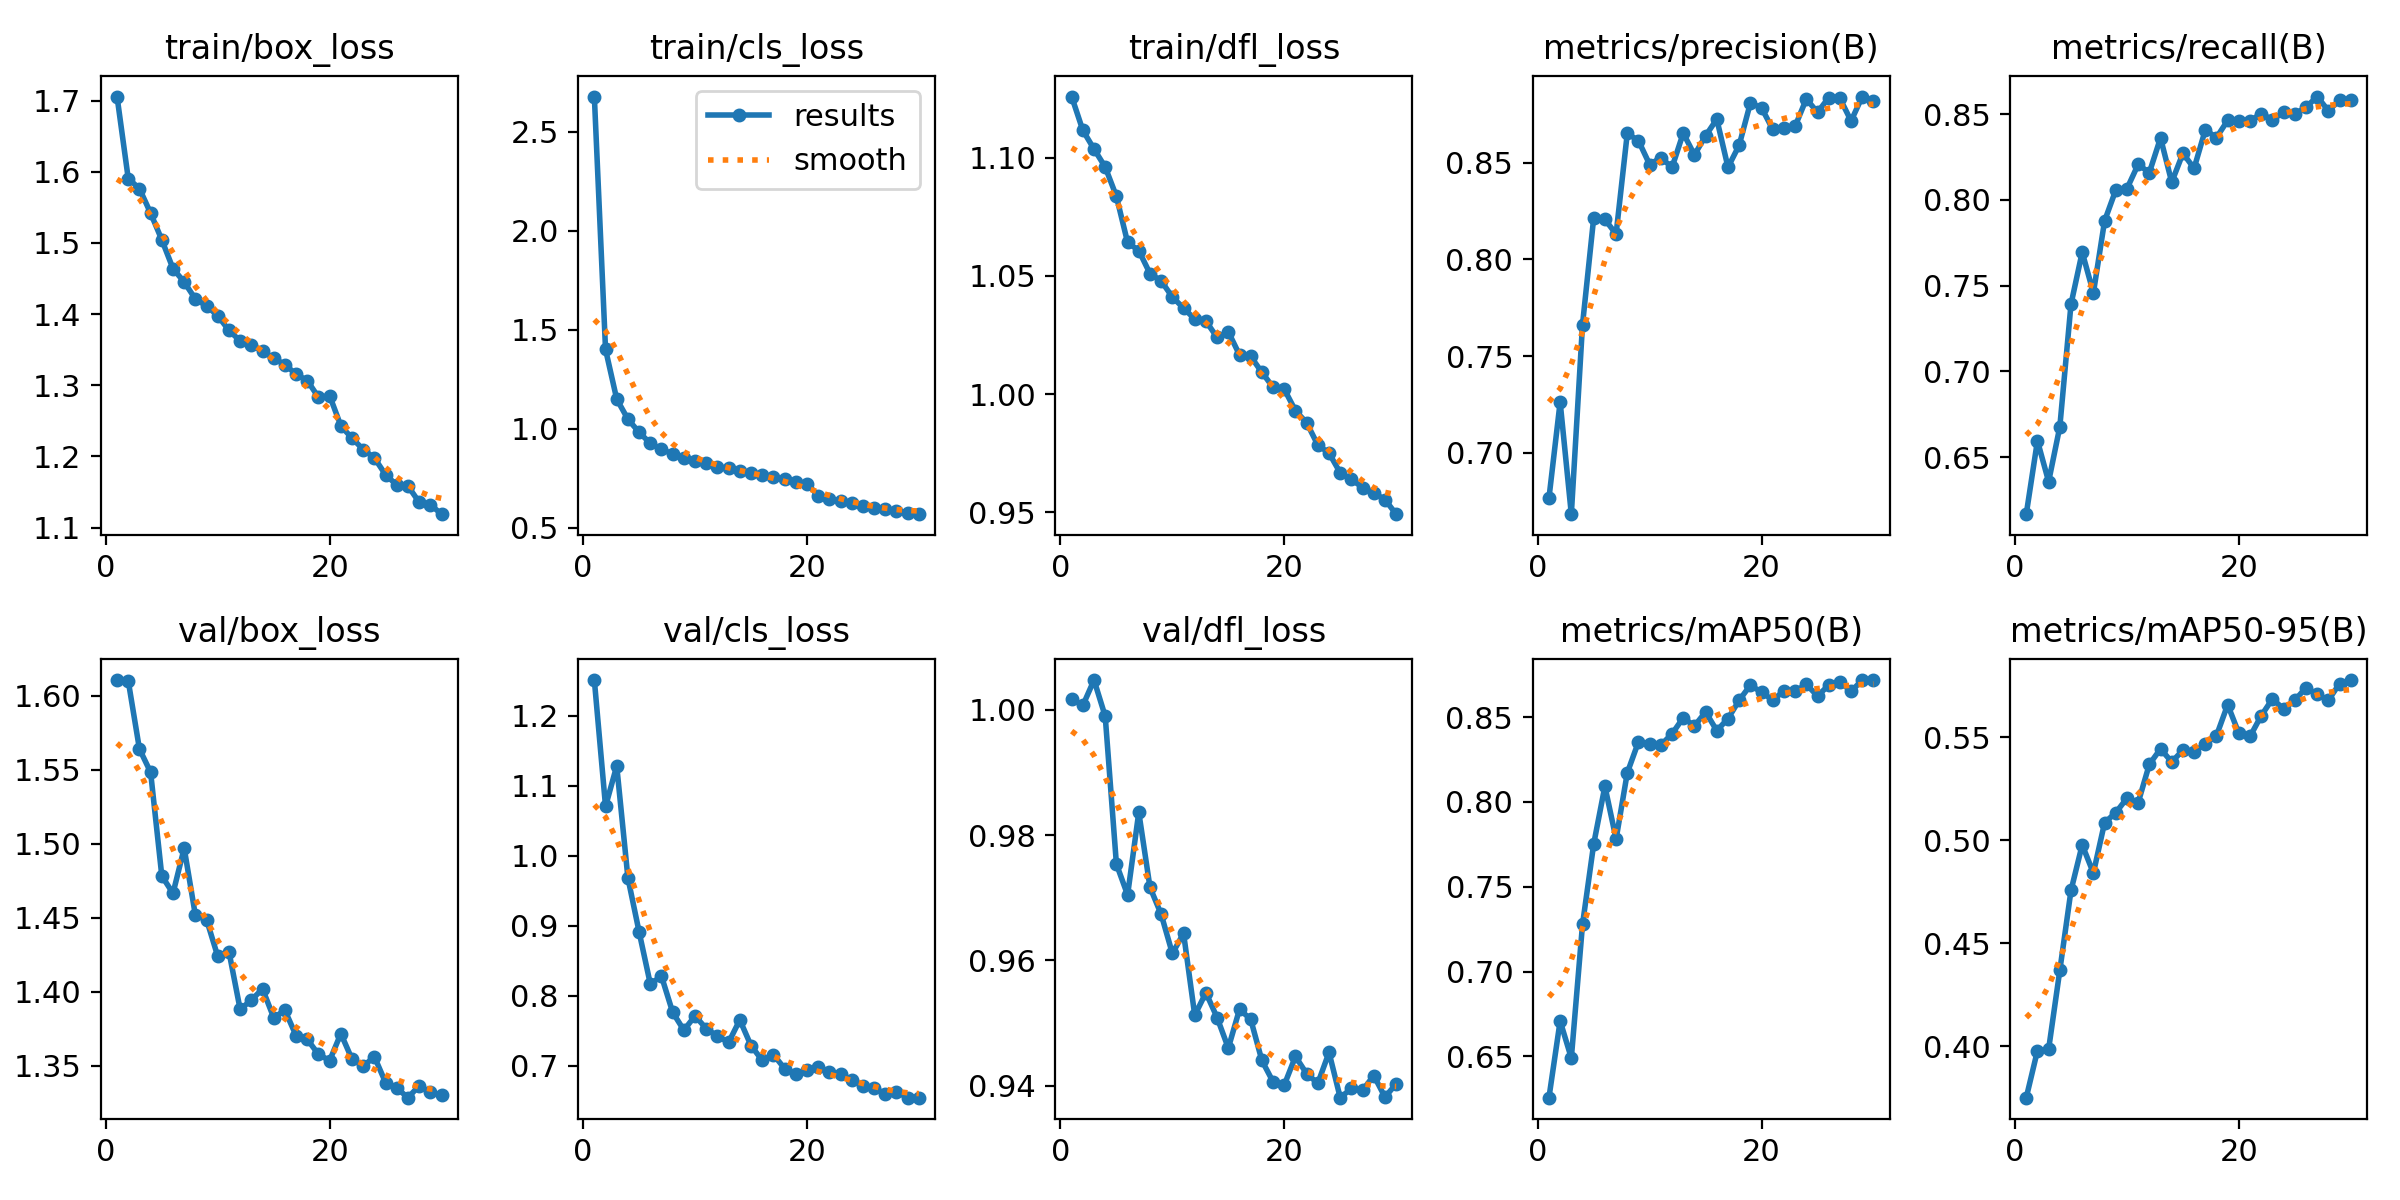

In [4]:
from IPython.display import Image, display
from pathlib import Path

Image("/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/results.png")

## Evaluation Overview

Evaluation on the validation split provides an unbiased estimate of how well the model generalizes beyond the training distribution. Because SentinelBlue strictly avoided validation contamination during augmentation and dataset balancing, the resulting metrics serve as a reliable indicator of real-world SAR detection capability. This separation is critical when the model is intended for operational reasoning tasks such as locating persons in maritime distress.

Diagnostic plots produced by Ultralytics help interpret performance beyond aggregate scores. The confusion matrix highlights class separation behaviour, revealing whether visually similar categories such as boats and jetskis introduce misclassification patterns. Precision–recall and F1 curves further contextualize the trade-off between detection sensitivity and false positives, which is especially important in SAR scenarios where missed detections may carry higher operational risk.

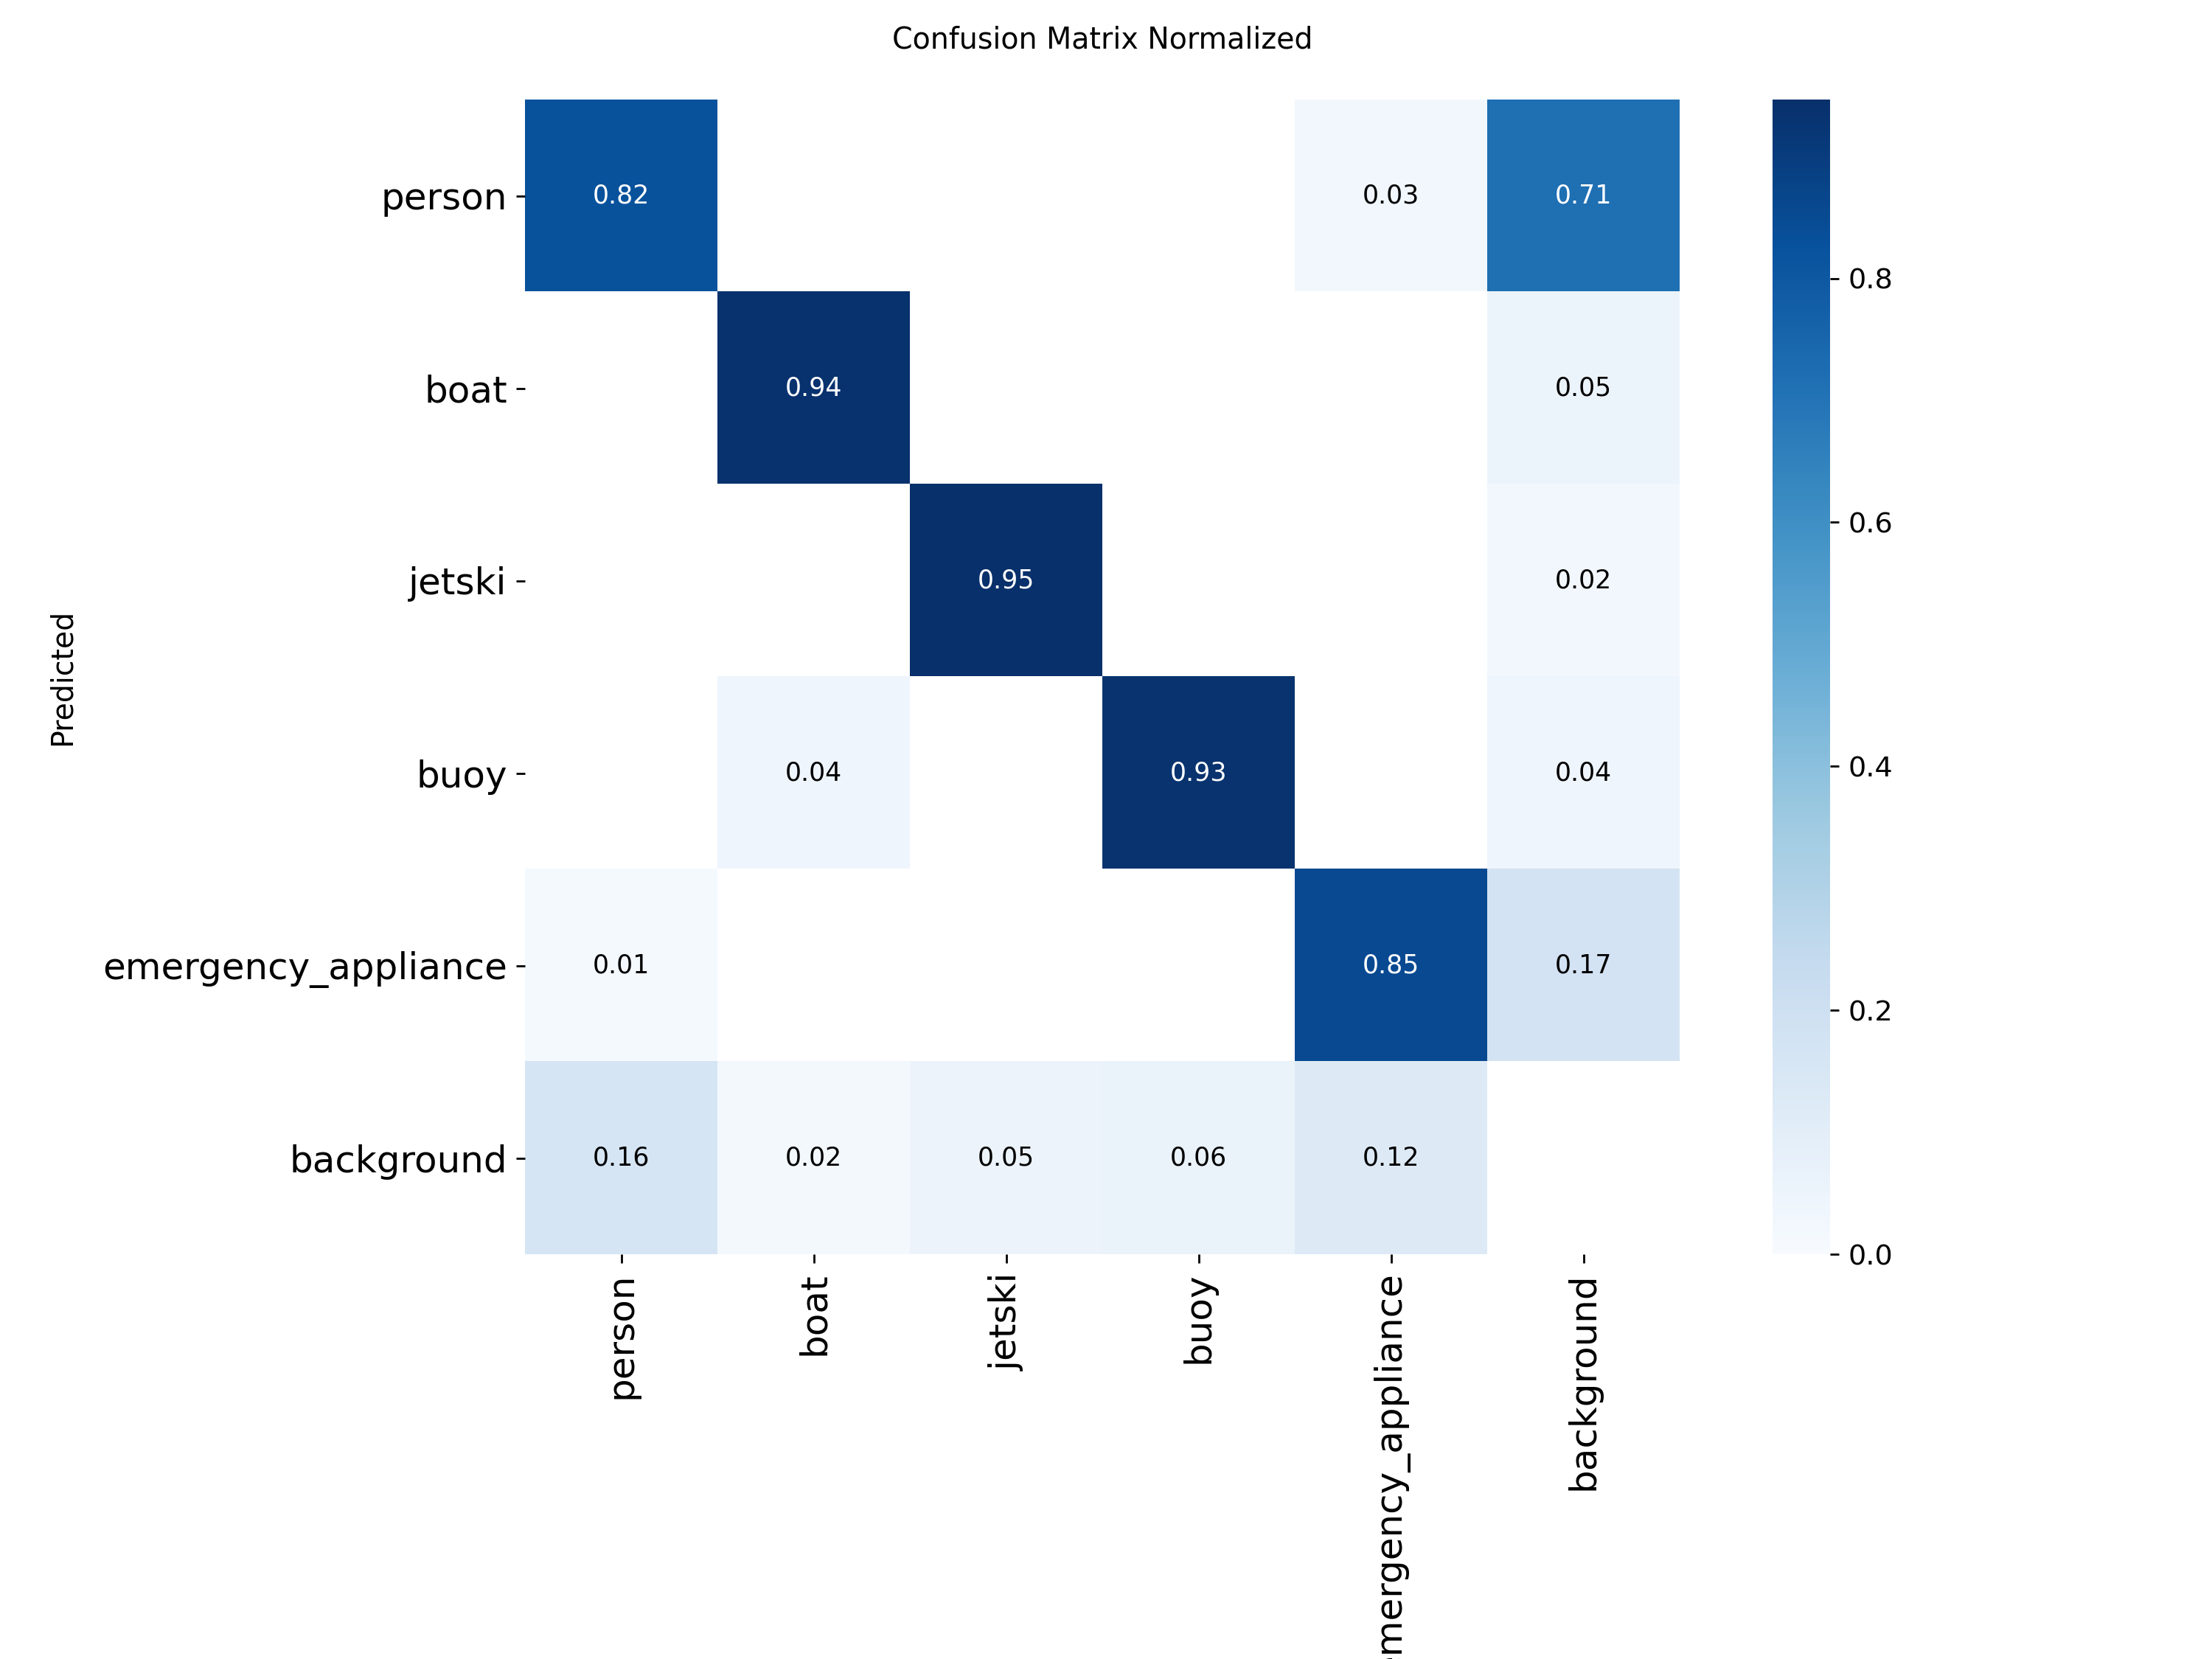

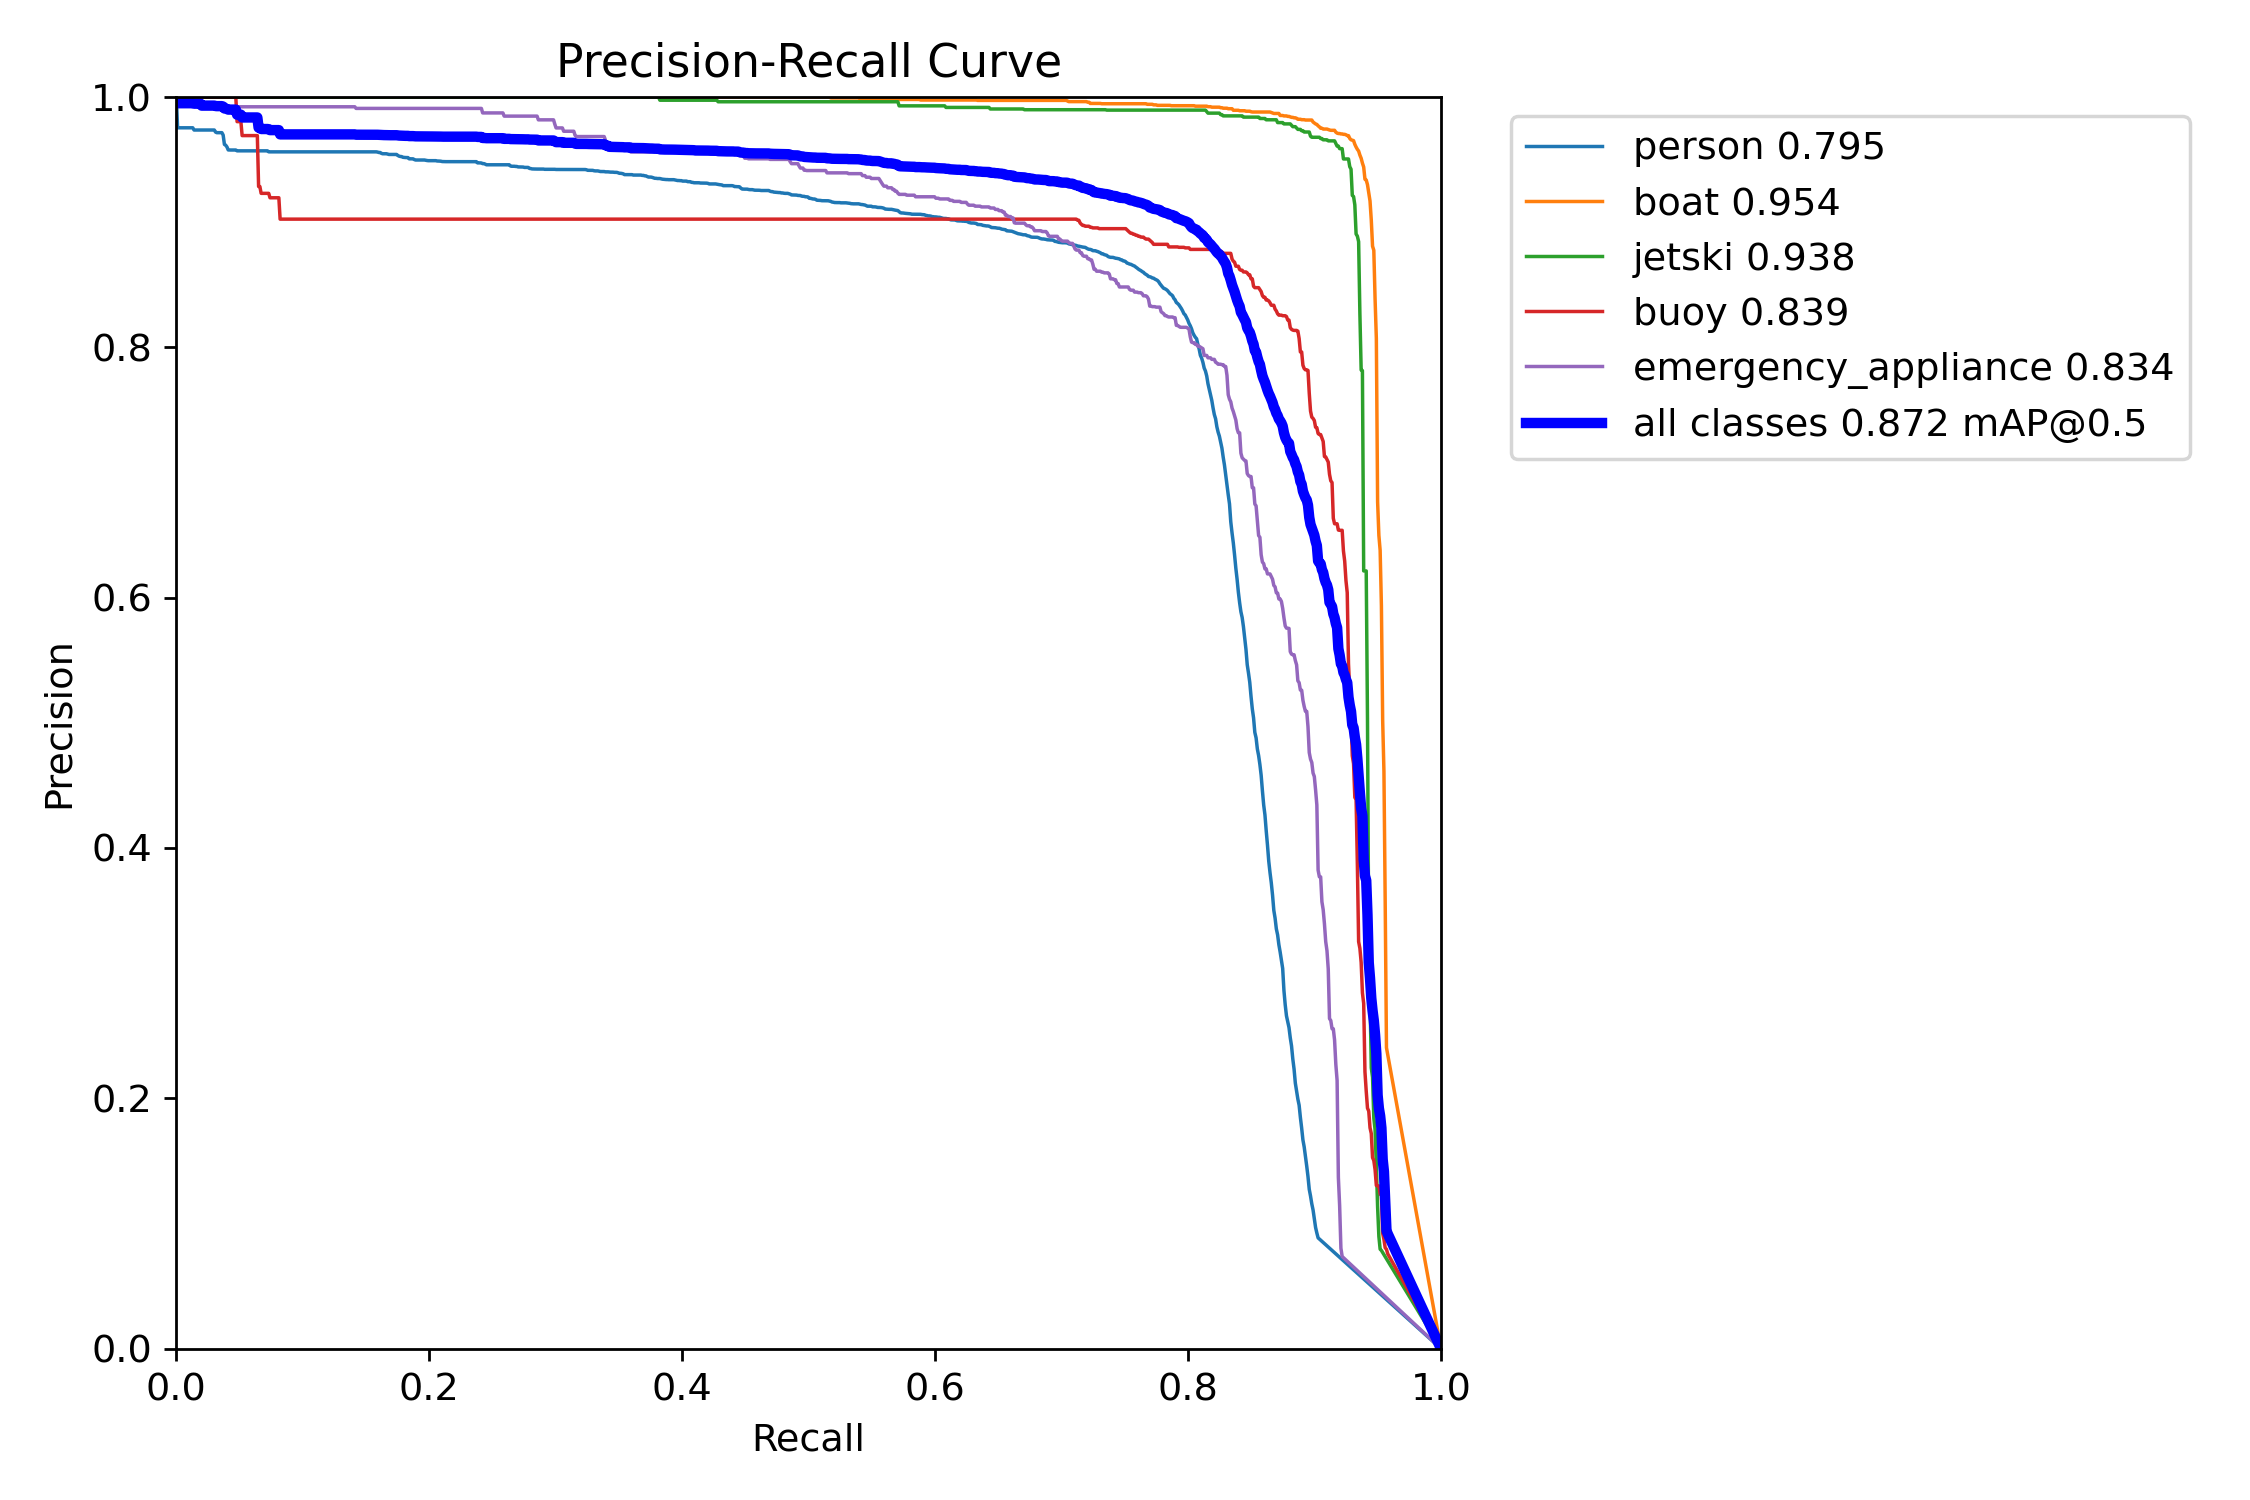

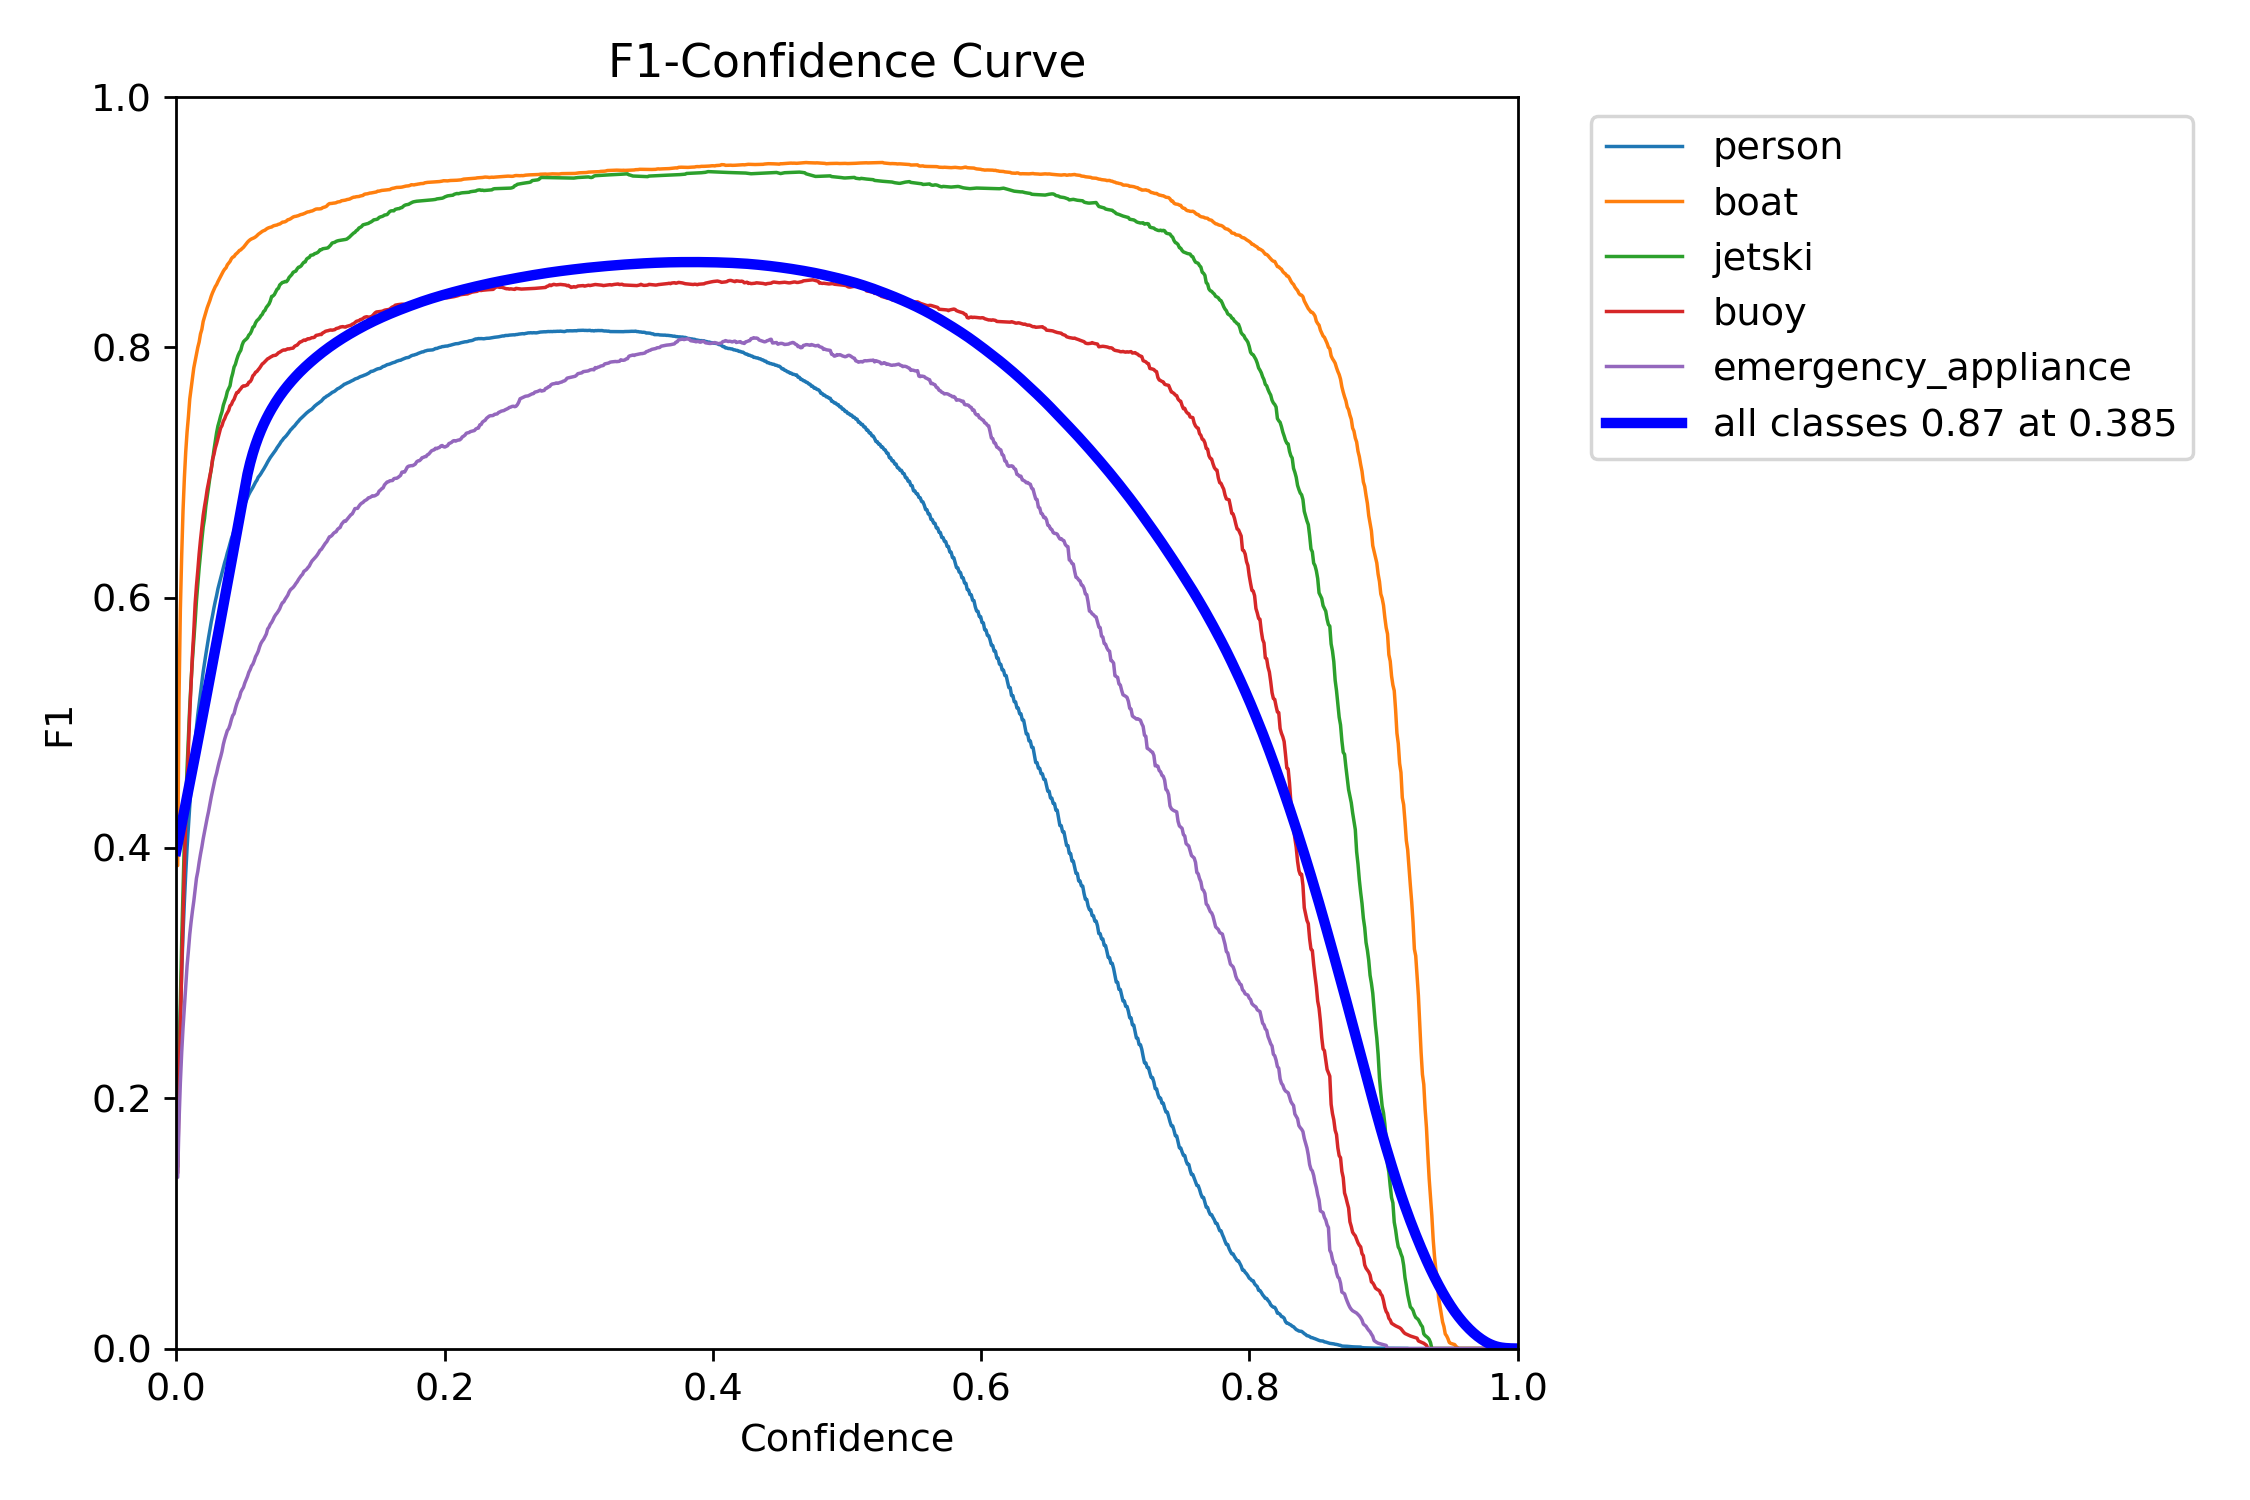

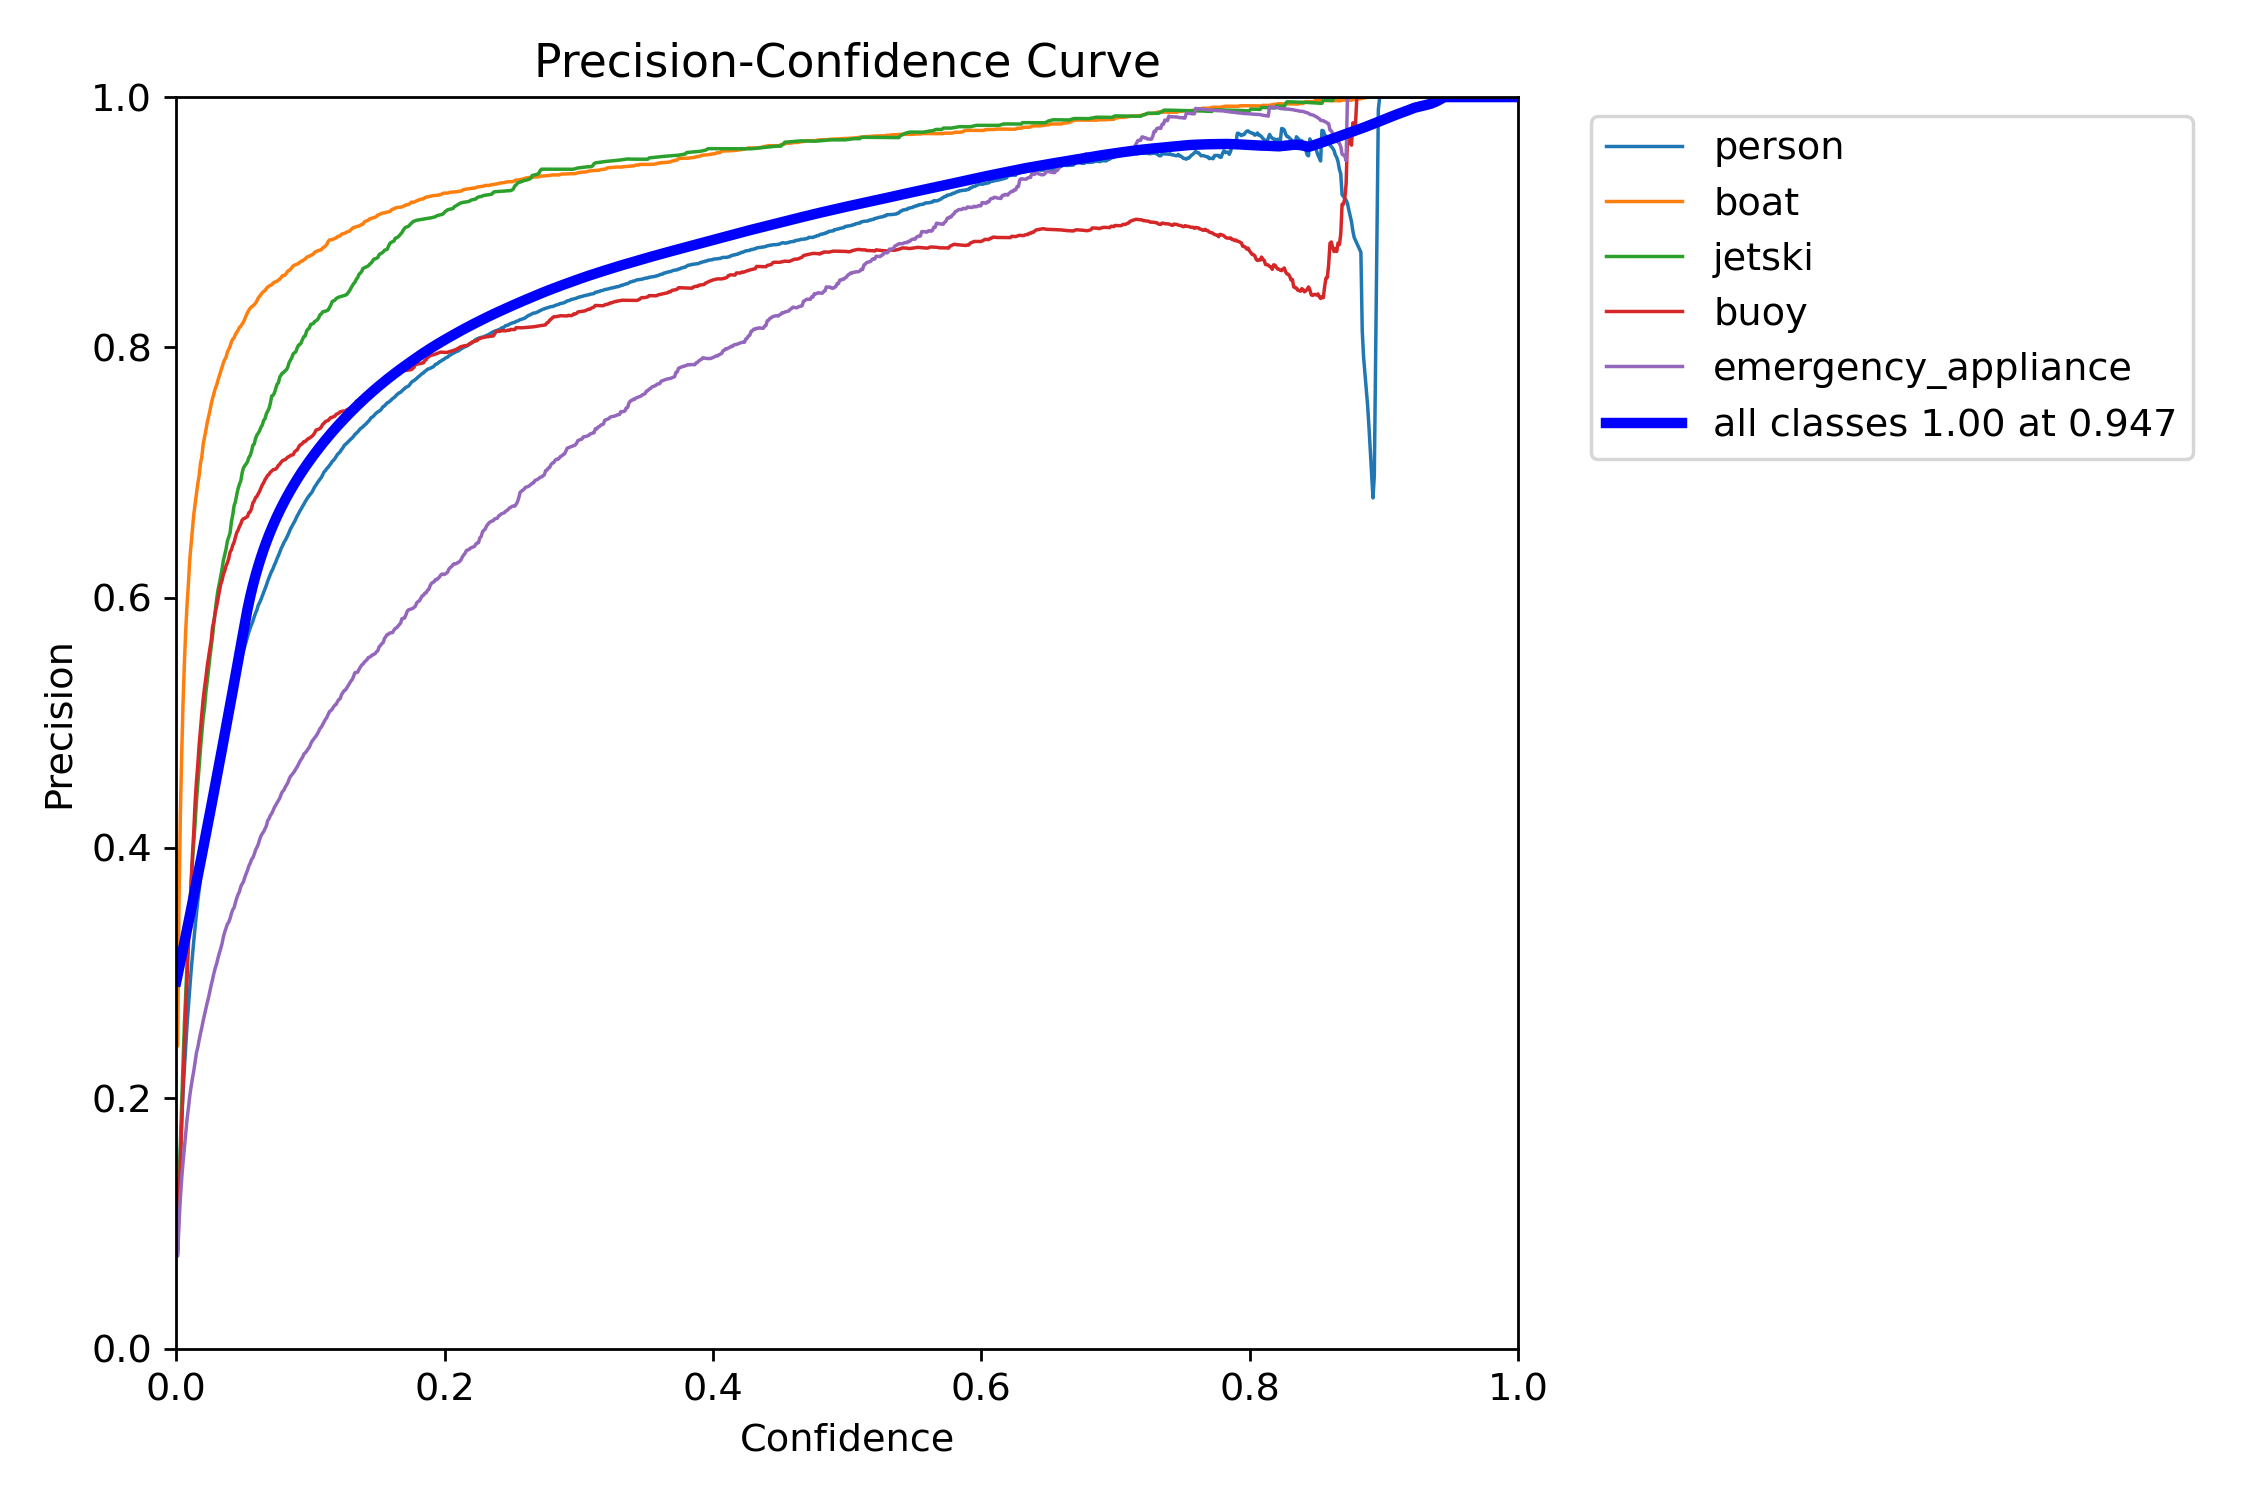

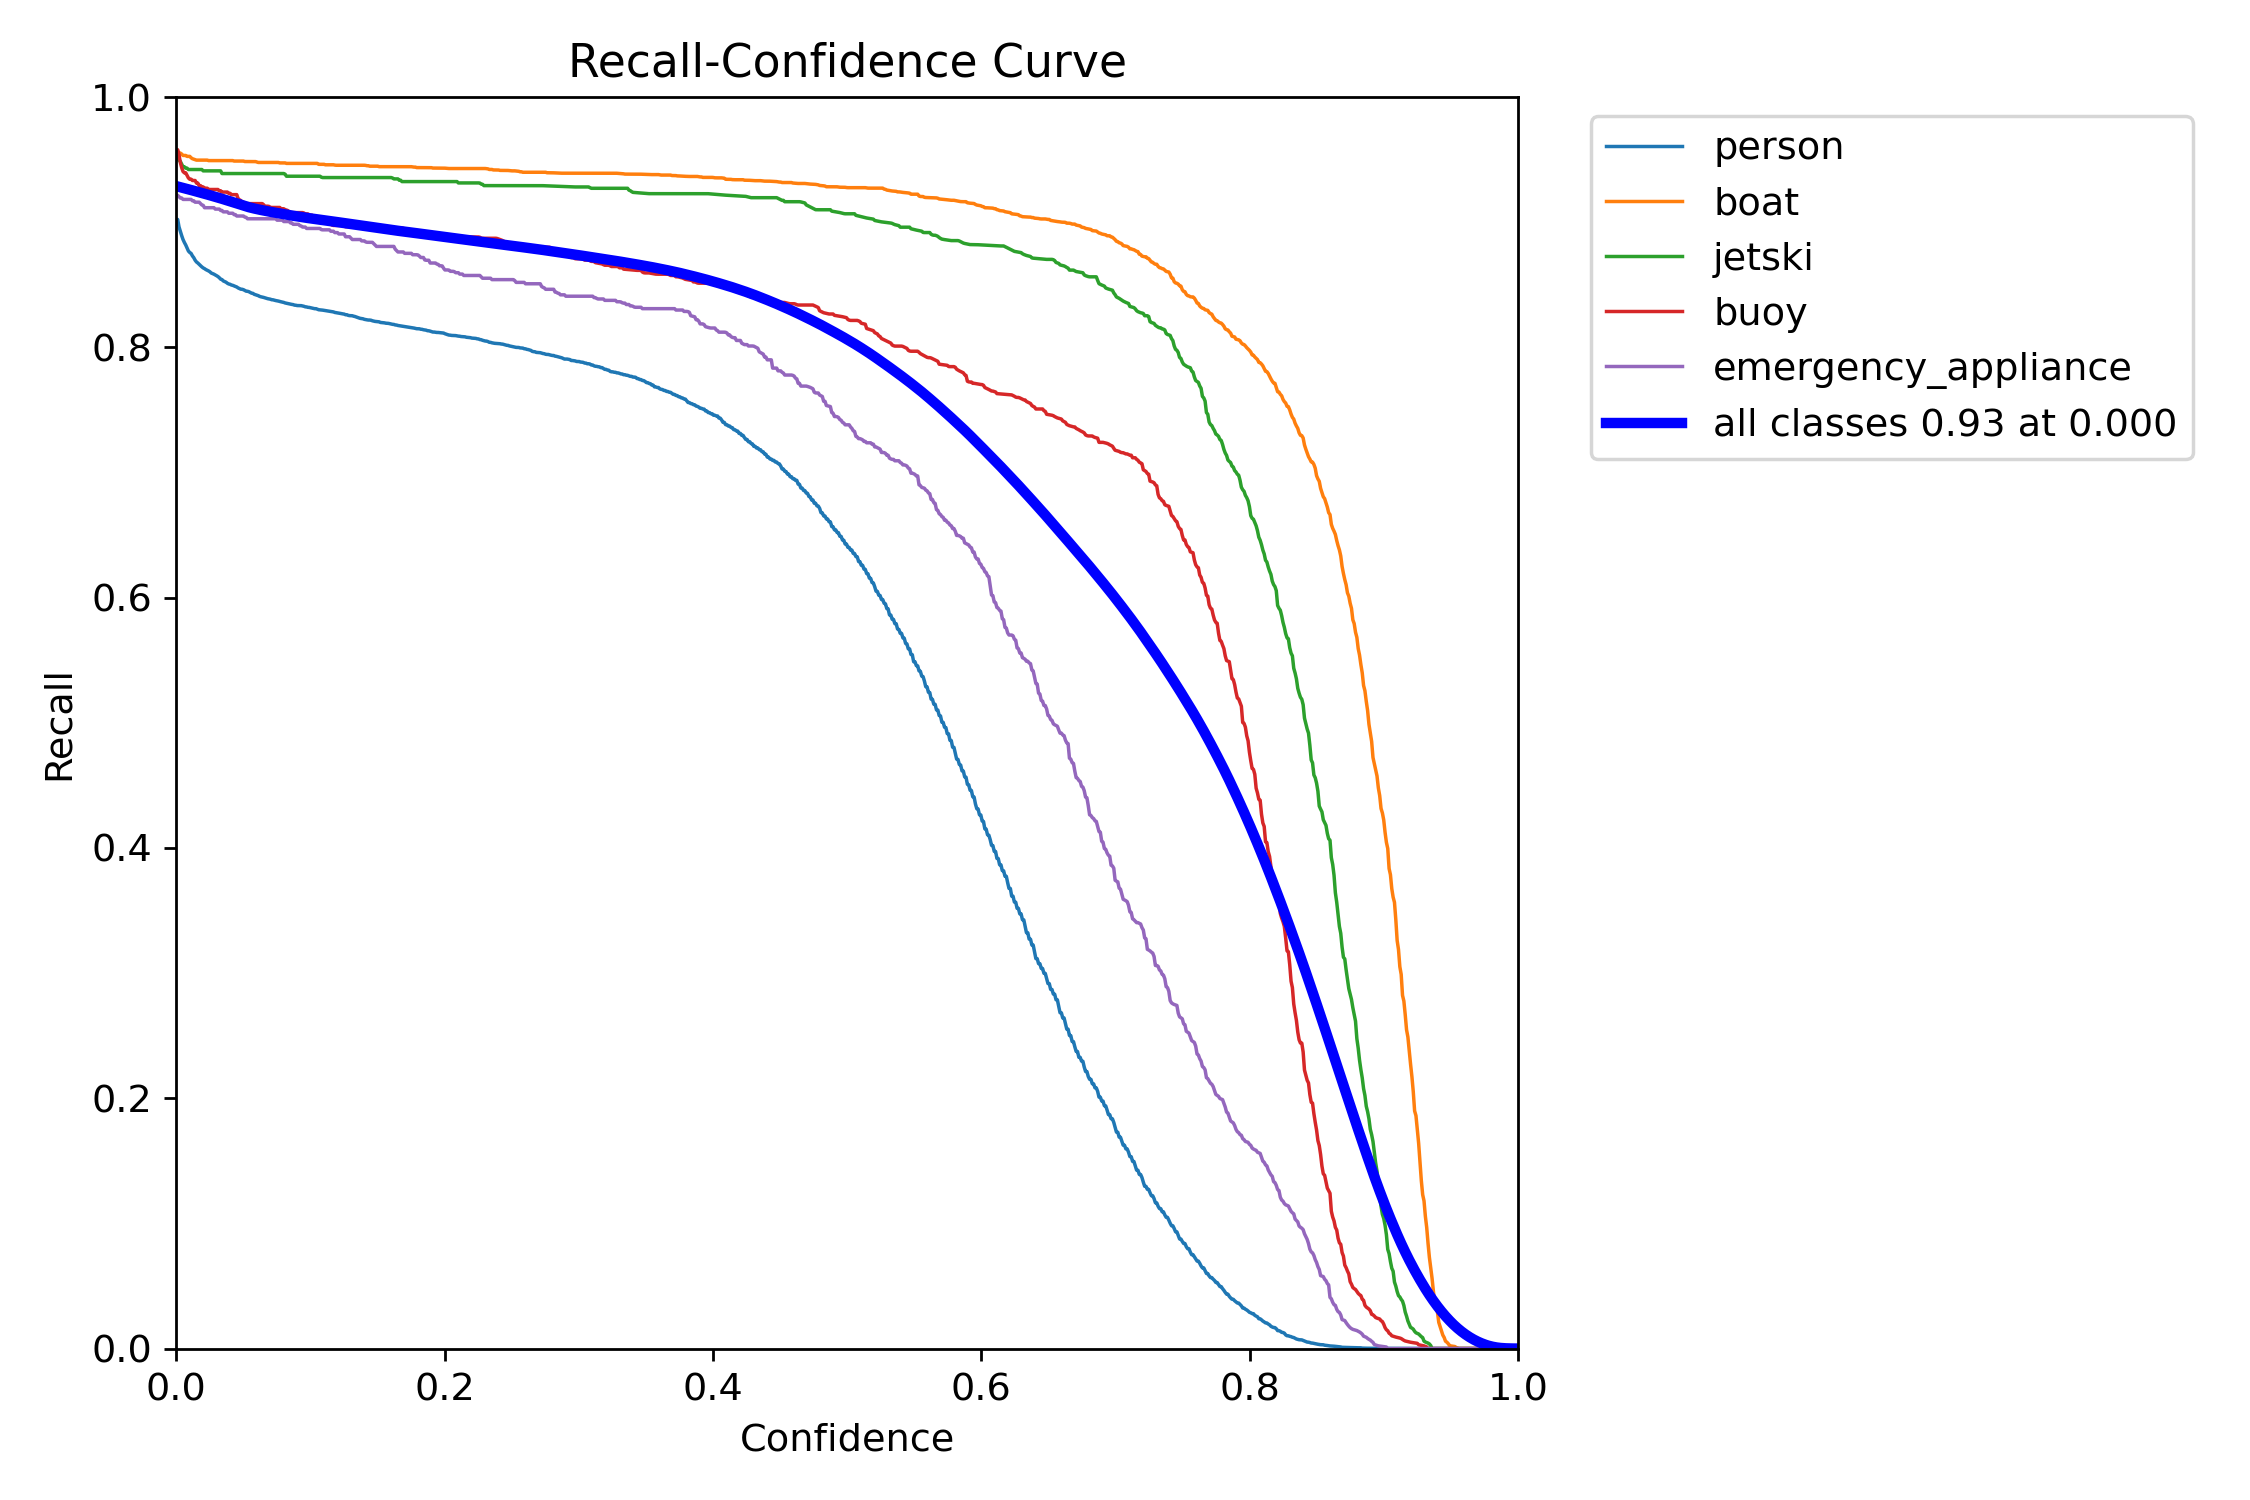

In [5]:
base_path = "/kaggle/working/runs/detect/training_iteration_1/training_iteration_1"
display(Image(f"{base_path}/confusion_matrix_normalized.png"))
display(Image(f"{base_path}/BoxPR_curve.png"))
display(Image(f"{base_path}/BoxF1_curve.png"))
display(Image(f"{base_path}/BoxP_curve.png"))
display(Image(f"{base_path}/BoxR_curve.png"))

## Sample Test Inference

Before running inference on the entire test split, a small subset of test images is used to verify the prediction pipeline and visually inspect model behaviour. This step acts as a practical sanity check, ensuring that the trained weights load correctly, inference parameters are appropriate, and detection outputs appear consistent with expectations.

Sampling a limited number of images allows rapid qualitative validation without incurring the computational cost of full test inference. This is particularly useful when working with large aerial datasets such as SentinelBlue, where early detection of configuration issues can prevent unnecessary reruns. The resulting visualizations provide an initial indication of localization accuracy, class consistency, and model sensitivity to small maritime targets.

In [6]:
# Create subset of test images
import random
import shutil
from pathlib import Path

test_path = Path("/kaggle/input/sentinelblue/test/images")
subset_dir = Path("/kaggle/working/test_subset_images")

subset_dir.mkdir(exist_ok=True)

all_images = list(test_path.glob("*.*"))
random_subset = random.sample(all_images, min(30, len(all_images)))

for img in random_subset:
    shutil.copy(img, subset_dir)

print("Subset folder created.")

Subset folder created.


In [7]:
# Run inference on subset
!yolo task=detect mode=predict \
model=/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/weights/best.pt \
conf=0.45 \
source=/kaggle/working/test_subset_images \
batch=16 \
save=True

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs

image 1/30 /kaggle/working/test_subset_images/1032_jpg.rf.7f0711c3d9d3fe3c1f852d1363c1fa50.jpg: 640x640 (no detections), 5.6ms
image 2/30 /kaggle/working/test_subset_images/172_jpg.rf.6710eba5e0dac5db66778e9bf6b714b2.jpg: 640x640 (no detections), 5.6ms
image 3/30 /kaggle/working/test_subset_images/1869_jpg.rf.4ac4250b716655f9adc1cf6ab801c6c8.jpg: 640x640 3 persons, 2 boats, 5.6ms
image 4/30 /kaggle/working/test_subset_images/2513_jpg.rf.842452a90a3b0906f901613ad458d9b3.jpg: 640x640 1 buoy, 5.6ms
image 5/30 /kaggle/working/test_subset_images/276_jpg.rf.05186bd4abcccfca6d6c44023c7229ae.jpg: 640x640 2 persons, 4 boats, 5.6ms
image 6/30 /kaggle/working/test_subset_images/2911_jpg.rf.bfd3b78fe2d252e46bb884890972df64.jpg: 640x640 1 person, 5.6ms
image 7/30 /kaggle/working/test_subset_images/3488_jpg.rf.2b7fcb435a82811041ca42cda7

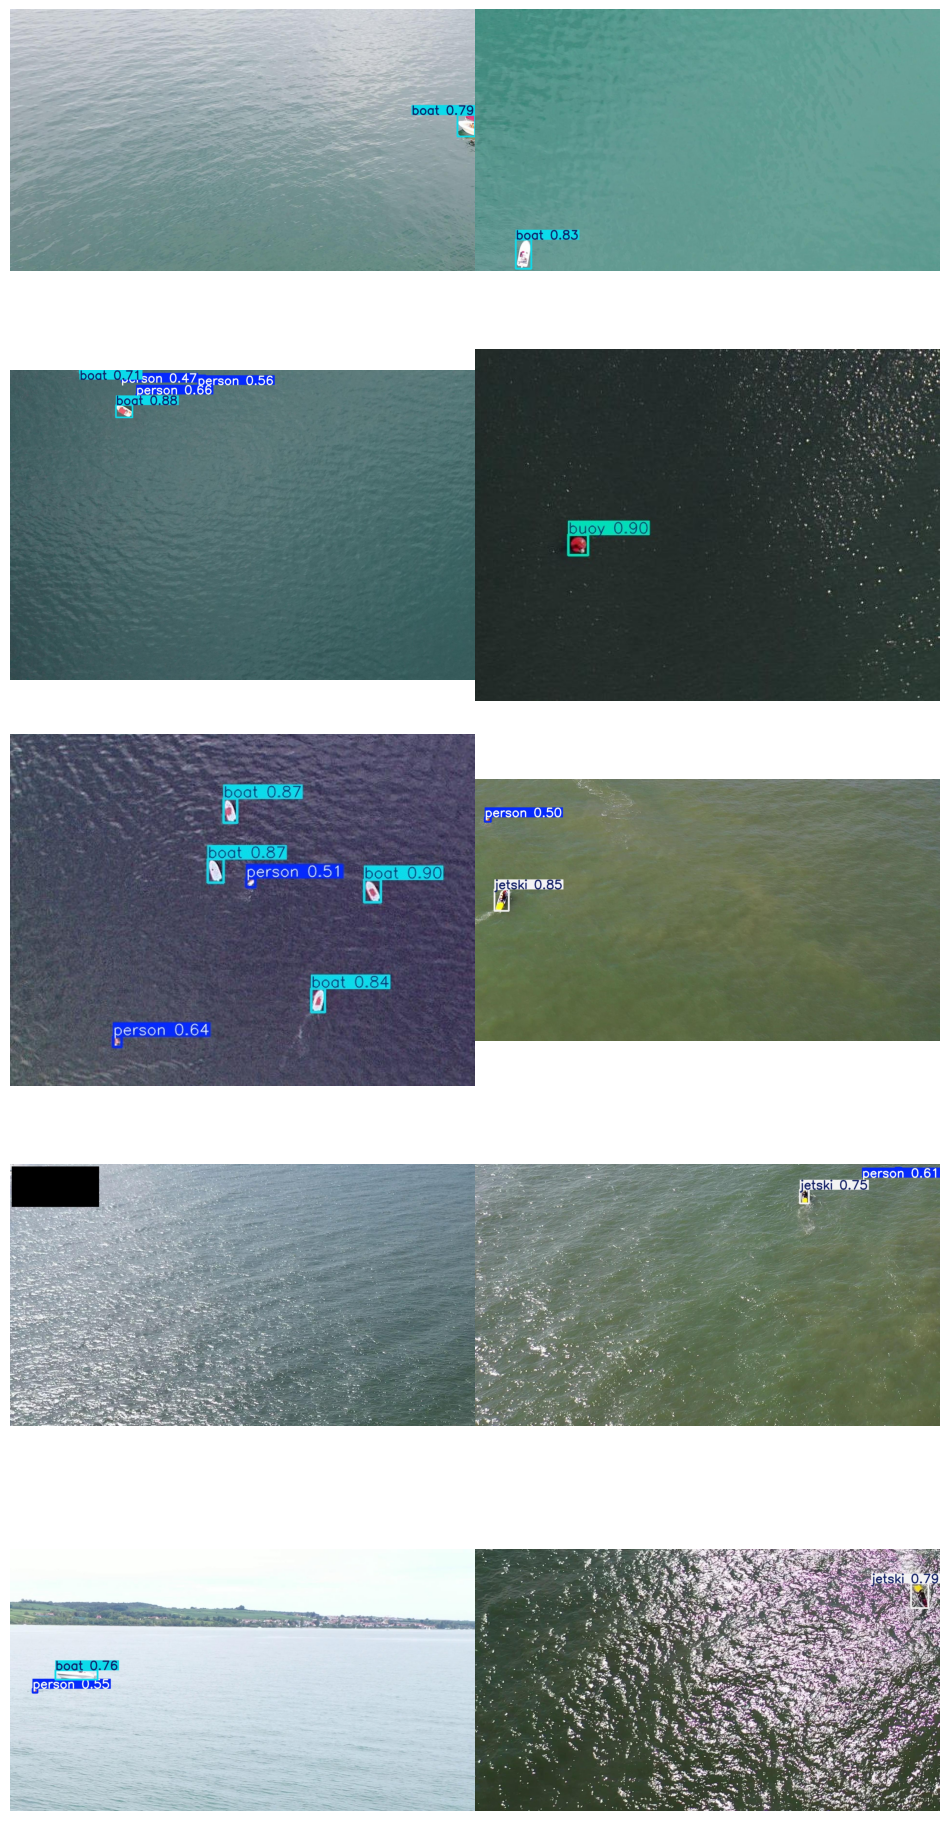

In [8]:
# Display predicted images
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

predict_path = "/kaggle/working/runs/detect/predict"

files = [f for f in os.listdir(predict_path) if f.endswith(".jpg")]
selected_files = random.sample(files, min(10, len(files)))

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 25))

for ax, file in zip(axes.flatten(), selected_files):
    img = Image.open(os.path.join(predict_path, file))
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## Full Test Set Inference

After verifying prediction behaviour on a small subset of test images, the model is applied to the entire test split to generate the final SentinelBlue inference outputs. This stage represents the closest approximation to real operational deployment because the model processes previously unseen maritime scenes without influencing training or validation metrics.

Running inference on the full test set ensures comprehensive qualitative coverage across diverse SAR scenarios, including variations in object scale, sea conditions, background clutter, and scene complexity. Persisting these outputs allows later comparison across SentinelBlue iterations and supports visual reporting within research documentation. This step produces the definitive prediction artifacts associated with the baseline experiment and serves as the reference for subsequent model improvements.

In [9]:
!yolo task=detect mode=predict \
model=/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/weights/best.pt \
conf=0.45 \
source=/kaggle/input/sentinelblue/test/images \
batch=16 \
save=True

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs

image 1/3279 /kaggle/input/sentinelblue/test/images/1003_jpg.rf.2d9a350a1162e6c914667131696a72ee.jpg: 640x640 (no detections), 4.8ms
image 2/3279 /kaggle/input/sentinelblue/test/images/1003_jpg.rf.58e0c25e35d04d0a81a5ed59b86e2bf1.jpg: 640x640 (no detections), 4.8ms
image 3/3279 /kaggle/input/sentinelblue/test/images/1003_jpg.rf.9abe799edba41b1a1dffff8c62c7855b.jpg: 640x640 1 person, 1 boat, 4.8ms
image 4/3279 /kaggle/input/sentinelblue/test/images/1003_jpg.rf.c694f63e1b792ac32bb423ee31207be7.jpg: 640x640 (no detections), 4.8ms
image 5/3279 /kaggle/input/sentinelblue/test/images/1018_jpg.rf.ae2699b0c678d6d5f13e7a52f90d767c.jpg: 640x640 (no detections), 4.8ms
image 6/3279 /kaggle/input/sentinelblue/test/images/1018_jpg.rf.de849ad536dd5e888b1a8f650f9111da.jpg: 640x640 3 persons, 2 boats, 4.8ms
image 7/3279 /kaggle/input/senti

## Exporting Predictions and Training Artifacts

To preserve experiment reproducibility and maintain organized records, both prediction outputs and training artifacts are archived after inference completes. Packaging these assets ensures that the SentinelBlue baseline can be reviewed, compared, and shared without rerunning training or inference. The prediction archive contains all annotated test images, enabling qualitative inspection and downstream analysis, while the metrics archive preserves checkpoints, plots, configuration files, and training logs.

Archiving experiment outputs is a critical component of a reproducible research workflow. Maintaining structured artifacts allows consistent comparison across future SentinelBlue iterations, supports documentation, and simplifies integration into reporting pipelines or deployment validation procedures.

In [10]:
# Zip prediction outputs
!zip -r iteration_1_results.zip /kaggle/working/runs/detect/predict

# Zip training artifacts (metrics, weights, plots)
!zip -r iteration_1_metrics.zip /kaggle/working/runs/detect/training_iteration_1/training_iteration_1

  adding: kaggle/working/runs/detect/predict/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/8060_jpg.rf.071e009bcacaf0d514b6dbe015396a43.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/7470_jpg.rf.2b52aa25fc2afba42013b597d02da239.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/3488_jpg.rf.2b7fcb435a82811041ca42cda74b04f4.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/predict/276_jpg.rf.05186bd4abcccfca6d6c44023c7229ae.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/8279_jpg.rf.35bf84b13d9233ec831755c51f78c8b5.jpg (deflated 20%)
  adding: kaggle/working/runs/detect/predict/5308_jpg.rf.eef64cdb6b3540a96e2c7b24c99bb4ea.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/8056_jpg.rf.a626239287c34bd31cd4cf2c07f3fbbd.jpg (deflated 6%)
  adding: kaggle/working/runs/detect/predict/172_jpg.rf.6710eba5e0dac5db66778e9bf6b714b2.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/7621_jpg.rf.2a941d64c869e6315ce2c5